Part A — Load the cleaned dataset

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Load the cleaned dataset from Person 1

df = pd.read_csv("../data/processed/hotel_bookings_cleaned.csv")

print("Dataset shape:", df.shape)
df.head()


Dataset shape: (87396, 37)


,IsCanceled,LeadTime,ArrivalDateYear,ArrivalDateMonth,ArrivalDateWeekNumber,ArrivalDateDayOfMonth,StaysInWeekendNights,StaysInWeekNights,Adults,Children,...,RequiredCarParkingSpaces,TotalOfSpecialRequests,ReservationStatus,ReservationStatusDate,Hotel,ArrivalDate,Season,TotalNights,TotalGuests,LeadTimeBand
0,0,342,2015,July,27,1,0,0,2,0.0,...,0,0,Check-Out,2015-07-01,Resort Hotel,2015-07-01,Summer,0,2.0,6mo+
1,0,737,2015,July,27,1,0,0,2,0.0,...,0,0,Check-Out,2015-07-01,Resort Hotel,2015-07-01,Summer,0,2.0,6mo+
2,0,7,2015,July,27,1,0,1,1,0.0,...,0,0,Check-Out,2015-07-02,Resort Hotel,2015-07-01,Summer,1,1.0,0-7d
3,0,13,2015,July,27,1,0,1,1,0.0,...,0,0,Check-Out,2015-07-02,Resort Hotel,2015-07-01,Summer,1,1.0,1-4wk
4,0,14,2015,July,27,1,0,2,2,0.0,...,0,1,Check-Out,2015-07-03,Resort Hotel,2015-07-01,Summer,2,2.0,1-4wk


Part B — Understand the target variable

In [21]:
print("========== BOOKING STATUS ==========")

print(df["IsCanceled"].value_counts())
cancellation_rate = df["IsCanceled"].mean() * 100

print("Overall cancellation rate:",
      round(cancellation_rate, 2), "%")

========== BOOKING STATUS ==========
IsCanceled
0    63371
1    24025
Name: count, dtype: int64
Overall cancellation rate: 27.49 %


Part C — The EDA structure

In [22]:
# EDA -HOTEL
#Does cancellation behaviour differ between City Hotel and Resort Hotel?
hotel_cancel = (
    df.groupby("Hotel")["IsCanceled"]
    .mean()
    .mul(100)
)

print(hotel_cancel)


Hotel
City Hotel      30.038557
Resort Hotel    23.480923
Name: IsCanceled, dtype: float64


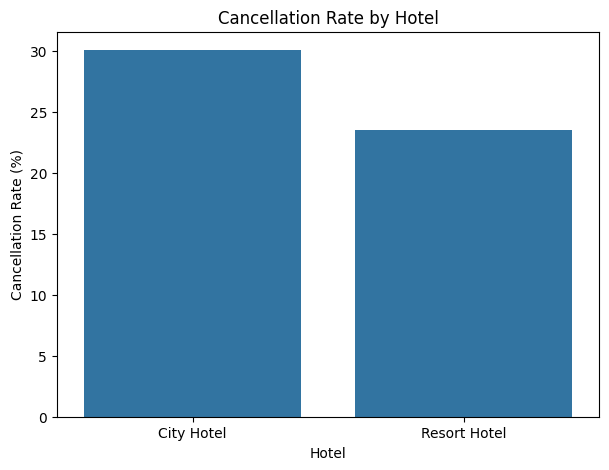

In [23]:
plt.figure(figsize=(7, 5))

sns.barplot(
    x=hotel_cancel.index,
    y=hotel_cancel.values
)

plt.title("Cancellation Rate by Hotel")
plt.xlabel("Hotel")
plt.ylabel("Cancellation Rate (%)")
plt.show()

MarketSegment
Undefined        100.000000
Online TA         35.346197
Groups            27.013355
Aviation          19.823789
Offline TA/TO     14.853481
Direct            14.715351
Complementary     12.535613
Corporate         12.108262
Name: IsCanceled, dtype: float64


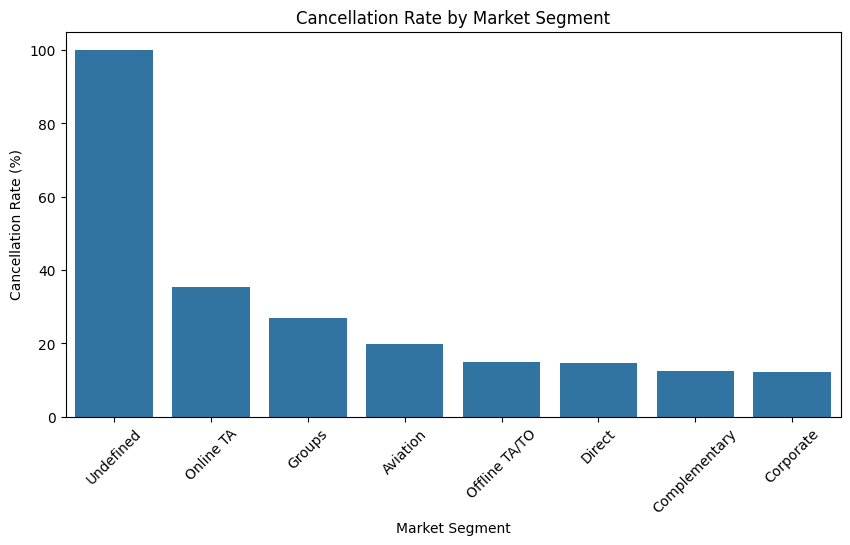

In [24]:
#EDA — Market Segment
segment_cancel = (
    df.groupby("MarketSegment")["IsCanceled"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

print(segment_cancel)
plt.figure(figsize=(10, 5))

sns.barplot(
    x=segment_cancel.index,
    y=segment_cancel.values
)

plt.title("Cancellation Rate by Market Segment")
plt.xlabel("Market Segment")
plt.ylabel("Cancellation Rate (%)")
plt.xticks(rotation=45)
plt.show()


MarketSegment
Undefined        100.000000
Online TA         35.346197
Groups            27.013355
Aviation          19.823789
Offline TA/TO     14.853481
Direct            14.715351
Complementary     12.535613
Corporate         12.108262
Name: IsCanceled, dtype: float64


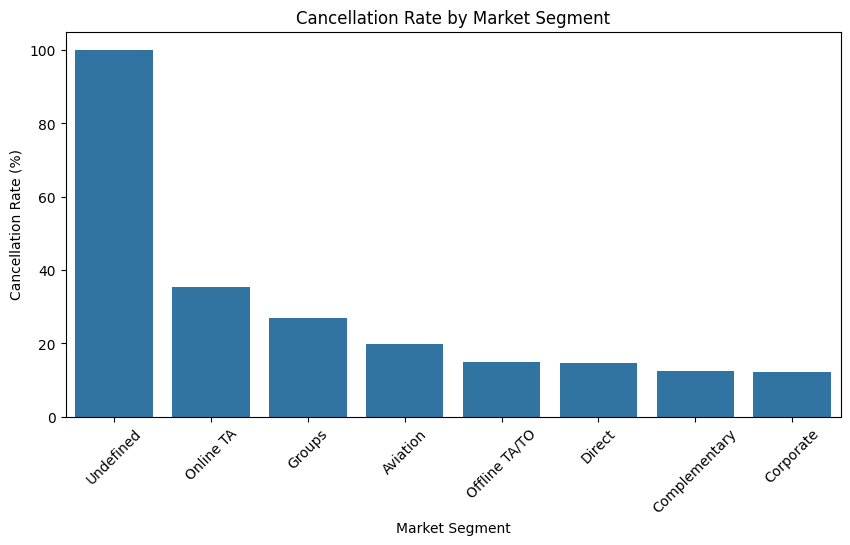

In [25]:
#EDA — Market Segment
#Does cancellation behaviour differ across market segments?
segment_cancel = (
    df.groupby("MarketSegment")["IsCanceled"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

print(segment_cancel)
plt.figure(figsize=(10, 5))

sns.barplot(
    x=segment_cancel.index,
    y=segment_cancel.values
)

plt.title("Cancellation Rate by Market Segment")
plt.xlabel("Market Segment")
plt.ylabel("Cancellation Rate (%)")
plt.xticks(rotation=45)
plt.show()

DepositType
No Deposit    86251
Non Refund     1038
Refundable      107
Name: count, dtype: int64


DepositType
Non Refund    94.701349
No Deposit    26.684908
Refundable    24.299065
Name: IsCanceled, dtype: float64


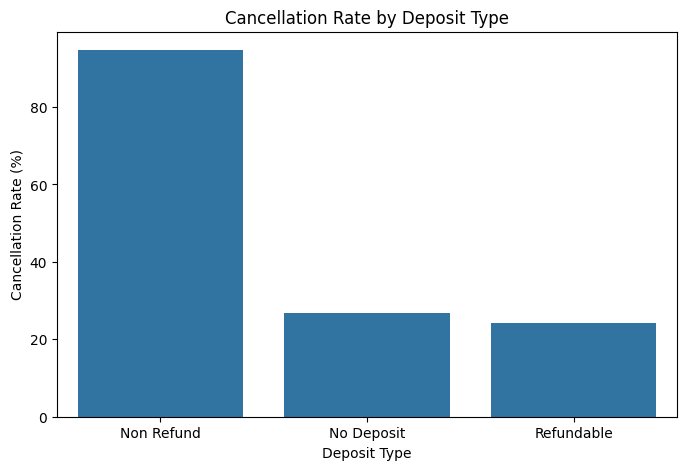

In [26]:
print(df["DepositType"].value_counts())
#eda-deposit type
deposit_cancel = (
    df.groupby("DepositType")["IsCanceled"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

print(deposit_cancel)
plt.figure(figsize=(8, 5))

sns.barplot(
    x=deposit_cancel.index,
    y=deposit_cancel.values
)

plt.title("Cancellation Rate by Deposit Type")
plt.xlabel("Deposit Type")
plt.ylabel("Cancellation Rate (%)")
plt.show()
# Is there an association between deposit type and cancellation status?


LeadTimeBand
0-7d      8.429851
1-3mo    32.008442
1-4wk    25.367197
3-6mo    34.983281
6mo+     39.736507
Name: IsCanceled, dtype: float64


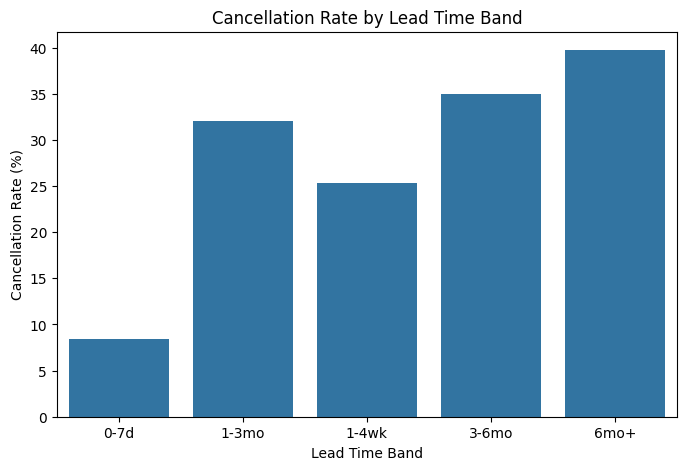

In [27]:
# EDA — Lead Time Band
leadtime_cancel = (
    df.groupby("LeadTimeBand")["IsCanceled"]
    .mean()
    .mul(100)
)

print(leadtime_cancel)
plt.figure(figsize=(8, 5))

sns.barplot(
    x=leadtime_cancel.index,
    y=leadtime_cancel.values
)

plt.title("Cancellation Rate by Lead Time Band")
plt.xlabel("Lead Time Band")
plt.ylabel("Cancellation Rate (%)")
plt.show()
#How does cancellation behaviour vary with the amount of time between booking and arrival?


0    2015-07-01
1    2015-07-01
2    2015-07-01
3    2015-07-01
4    2015-07-01
Name: ArrivalDate, dtype: str
Season
Summer    29079
Spring    23776
Autumn    18619
Winter    15922
Name: count, dtype: int64
Season
Autumn    23.298781
Spring    28.099764
Summer    31.551979
Winter    24.061048
Name: IsCanceled, dtype: float64


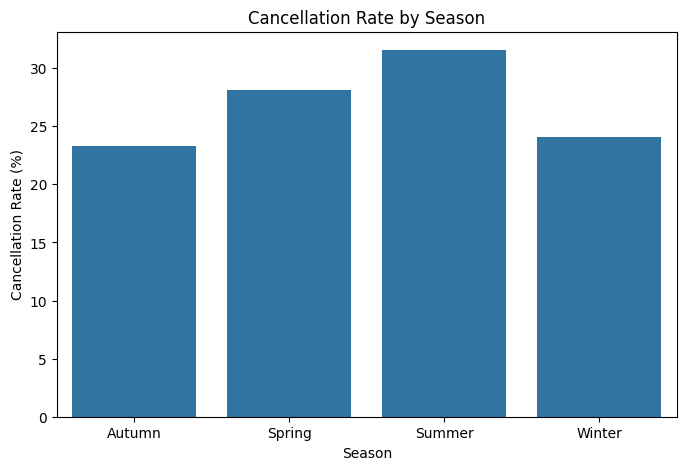

In [35]:
#EDA — Season
print(df["ArrivalDate"].head())
print(df["Season"].value_counts())
season_cancel = (
    df.groupby("Season")["IsCanceled"]
    .mean()
    .mul(100)
)

print(season_cancel)
plt.figure(figsize=(8, 5))

sns.barplot(
    x=season_cancel.index,
    y=season_cancel.values
)

plt.title("Cancellation Rate by Season")
plt.xlabel("Season")
plt.ylabel("Cancellation Rate (%)")
plt.show()


Part D — Cancelled vs Non-Cancelled Overlay Plots

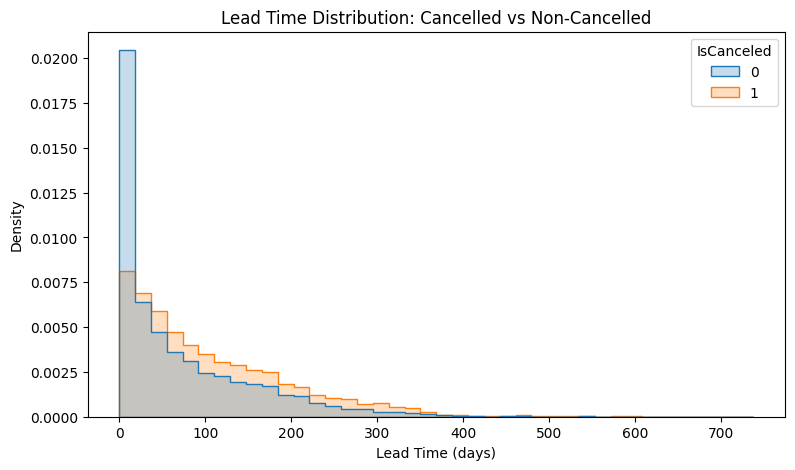

In [29]:
#1. Lead Time
plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="LeadTime",
    hue="IsCanceled",
    bins=40,
    stat="density",
    common_norm=False,
    element="step"
)

plt.title("Lead Time Distribution: Cancelled vs Non-Cancelled")
plt.xlabel("Lead Time (days)")
plt.ylabel("Density")
plt.show()
#Do cancelled and non-cancelled bookings have different lead-time distributions?

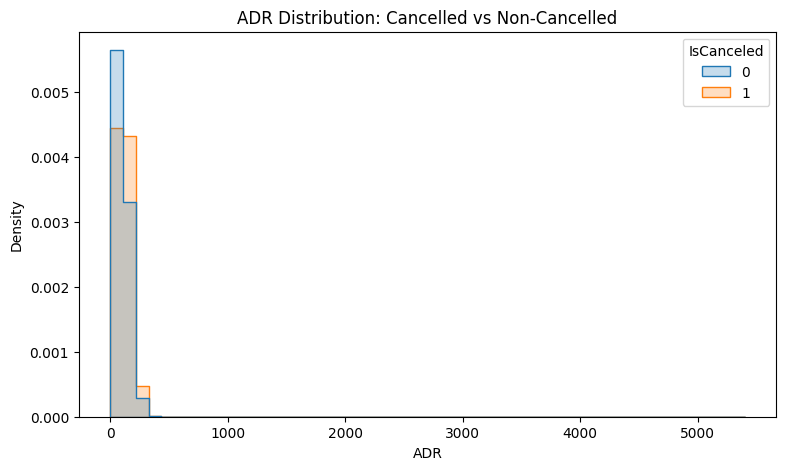

In [30]:
#ADR
plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="ADR",
    hue="IsCanceled",
    bins=50,
    stat="density",
    common_norm=False,
    element="step"
)

plt.title("ADR Distribution: Cancelled vs Non-Cancelled")
plt.xlabel("ADR")
plt.ylabel("Density")
plt.show()

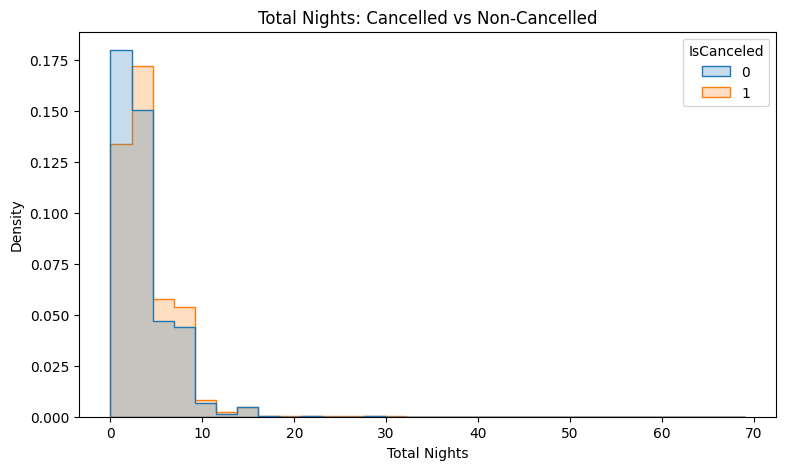

In [31]:
# 3 Total Nights
plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="TotalNights",
    hue="IsCanceled",
    bins=30,
    stat="density",
    common_norm=False,
    element="step"
)

plt.title("Total Nights: Cancelled vs Non-Cancelled")
plt.xlabel("Total Nights")
plt.ylabel("Density")
plt.show()


Part E — Probability

In [32]:
#E1. Basic probability
p_cancelled = df["IsCanceled"].mean()

print("P(Cancelled) =", round(p_cancelled, 4))
#E2. Probability of a hotel type
p_city = (df["Hotel"] == "City Hotel").mean()

print("P(City Hotel) =", round(p_city, 4))
p_city = (df["Hotel"] == "City Hotel").mean()

p_resort = (df["Hotel"] == "Resort Hotel").mean()

print("P(Resort Hotel) =", round(p_resort, 4))
#E3. Joint probability
p_city_and_cancelled = (
    ((df["Hotel"] == "City Hotel") &
     (df["IsCanceled"] == 1))
    .mean()
)

print(
    "P(City Hotel AND Cancelled) =",
    round(p_city_and_cancelled, 4)
)
# E4 Conditional probability
p_cancel_given_city = (
    df.loc[df["Hotel"] == "City Hotel", "IsCanceled"]
    .mean()
)

print(
    "P(Cancelled | City Hotel) =",
    round(p_cancel_given_city, 4)
)
#E5. Another conditional probability
p_cancel_given_nonrefund = (
    df.loc[df["DepositType"] == "Non Refund", "IsCanceled"]
    .mean()
)

print(
    "P(Cancelled | Non Refund) =",
    round(p_cancel_given_nonrefund, 4)
)




P(Cancelled) = 0.2749
P(City Hotel) = 0.6113
P(Resort Hotel) = 0.3887
P(City Hotel AND Cancelled) = 0.1836
P(Cancelled | City Hotel) = 0.3004
P(Cancelled | Non Refund) = 0.947


PART F-BAYES THEOREM


In [37]:
#Calculate the components
p_city = (df["Hotel"] == "City Hotel").mean()

p_cancelled = (df["IsCanceled"] == 1).mean()

p_cancel_given_city = (
    df.loc[df["Hotel"] == "City Hotel", "IsCanceled"]
    .mean()
)

#bayes
p_city_given_cancelled = (
    p_cancel_given_city * p_city
) / p_cancelled

print(
    "P(City Hotel | Cancelled) =",
    round(p_city_given_cancelled, 4)
)
#verify
direct_probability = (
    df.loc[df["IsCanceled"] == 1, "Hotel"]
    .eq("City Hotel")
    .mean()
)

print(
    "Direct calculation =",
    round(direct_probability, 4)
)

P(City Hotel | Cancelled) = 0.668
Direct calculation = 0.668
